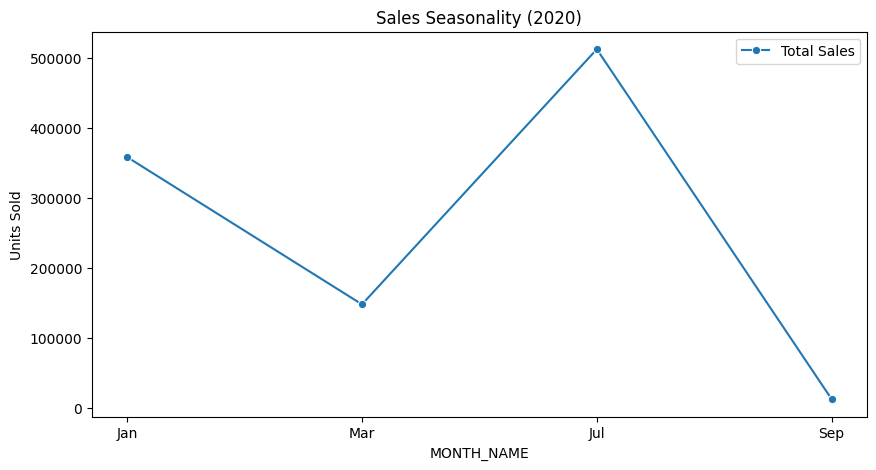

/tmp/ipython-input-302065131.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_suppliers, x='TOTAL SALES', y='SUPPLIER', palette='viridis')


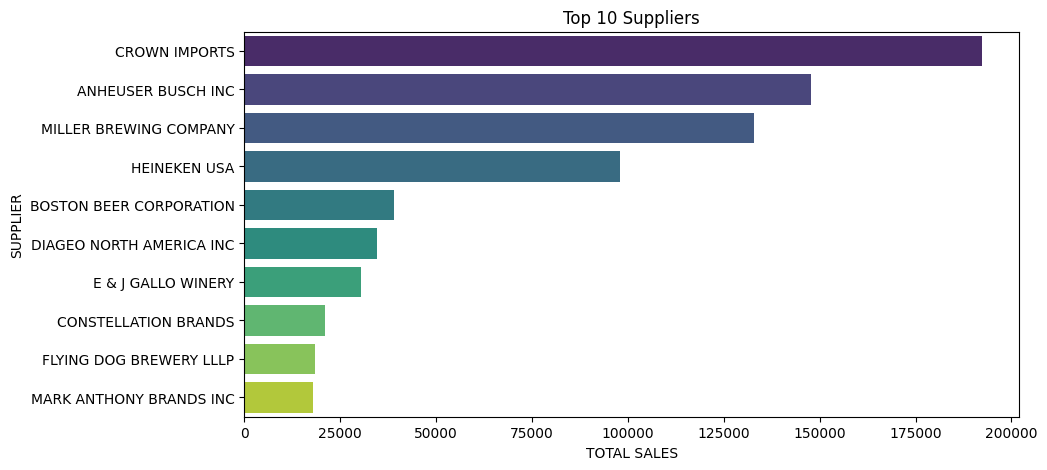

Total Sales Volume: 1,031,117.87


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os

# 1. Load the data
file_name = 'Retail and wherehouse Sale (1).csv'

try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print(f"File '{file_name}' not found. Please upload the file.")
    uploaded = files.upload()
    if file_name in uploaded:
        print(f"'{file_name}' uploaded successfully. Retrying to load data.")
        df = pd.read_csv(file_name)
    else:
        print(f"Failed to upload '{file_name}'. Please ensure the correct file is selected.")
        # Optionally re-raise the error or handle it as appropriate
        raise # Re-raise the error if the file still isn't there

# 2. Data Cleaning & Preparation
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(0)
df['TOTAL SALES'] = df['RETAIL SALES'] + df['WAREHOUSE SALES']

# 3. Create Monthly Trends
month_map = {1: 'Jan', 3: 'Mar', 7: 'Jul', 9: 'Sep'}
monthly = df.groupby('MONTH')[['RETAIL SALES', 'WAREHOUSE SALES', 'TOTAL SALES']].sum().reset_index()
monthly['MONTH_NAME'] = monthly['MONTH'].map(month_map)

# 4. Visualization: Monthly Trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x='MONTH_NAME', y='TOTAL SALES', marker='o', label='Total Sales')
plt.title('Sales Seasonality (2020)')
plt.ylabel('Units Sold')
plt.show()

# 5. Top 10 Suppliers Bar Chart
top_suppliers = df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=top_suppliers, x='TOTAL SALES', y='SUPPLIER', palette='viridis')
plt.title('Top 10 Suppliers')
plt.show()

# Summary Printout
print(f"Total Sales Volume: {df['TOTAL SALES'].sum():,.2f}")